<img src="./assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Lab: Simple Linear Regression with Sacramento Real Estate Data

---

In this lab you will hone your exploratory data analysis (EDA) skills and practice constructing linear regressions on a data set of Sacramento real estate sales.  The data set contains information on qualities of the property, location of the property, and time of sale.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

### 1. Read in the Sacramento housing data set.

The file is stored in the `data` subfolder.

In [2]:
housing = pd.read_csv('./data/sacramento_real_estate_transactions.csv')

### 2. Conduct exploratory data analysis on this data set. 

If you discover any issues with the data, fix them to the best of your ability. Report any notable findings.

__Note:__
- Assign the correct data type to each column.
- Look for missing values and determine how to handle them. Keep in mind that most machine learning models cannot process null values.
- Check the value ranges for numerical and categorical columns to identify any anomalies.
- Examine the distribution of values and investigate potential outliers.

In [3]:
housing.head()

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,Residential,Wed May 21 00:00:00 EDT 2008,59222,38.631913,-121.434879
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,Wed May 21 00:00:00 EDT 2008,68212,38.478902,-121.431028
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,Residential,Wed May 21 00:00:00 EDT 2008,68880,38.618305,-121.443839
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,Residential,Wed May 21 00:00:00 EDT 2008,69307,38.616835,-121.439146
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,Residential,Wed May 21 00:00:00 EDT 2008,81900,38.519470,-121.435768


In [4]:
housing.dtypes

street           str
city             str
zip            int64
state            str
beds           int64
baths          int64
sq__ft         int64
type             str
sale_date        str
price          int64
latitude     float64
longitude    float64
dtype: object

In [5]:
housing['zip'] = housing['zip'].astype(str)

In [6]:
housing['sale_date'] =housing['sale_date'].str.replace('EDT','')

In [7]:
housing['sale_date'] = pd.to_datetime(housing['sale_date'])

In [8]:
housing['sale_date']

0     2008-05-21
1     2008-05-21
2     2008-05-21
3     2008-05-21
4     2008-05-21
         ...    
980   2008-05-15
981   2008-05-15
982   2008-05-15
983   2008-05-15
984   2008-05-15
Name: sale_date, Length: 985, dtype: datetime64[us]

In [9]:
housing['type'].value_counts()

type
Residential     917
Condo            54
Multi-Family     13
Unkown            1
Name: count, dtype: int64

In [10]:
housing.head()

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,Residential,2008-05-21,59222,38.631913,-121.434879
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,2008-05-21,68212,38.478902,-121.431028
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,Residential,2008-05-21,68880,38.618305,-121.443839
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,Residential,2008-05-21,69307,38.616835,-121.439146
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,Residential,2008-05-21,81900,38.519470,-121.435768


In [11]:
housing.isnull().sum()

street       0
city         0
zip          0
state        0
beds         0
baths        0
sq__ft       0
type         0
sale_date    0
price        0
latitude     0
longitude    0
dtype: int64

In [12]:
print(housing.duplicated().sum())

3


In [13]:
housing_cleaned = housing[
    (housing["price"] > 0) &
    (housing["sq__ft"] >0)]

housing_cleaned.shape

(813, 12)

In [14]:
print((housing['sq__ft'] == 0).sum())
print((housing['price'] == 0).sum())
print((housing['baths'] == 0).sum())

171
0
108


In [15]:
housing = housing[
    (housing['sq__ft'] >0)&
    (housing['price'] > 0) &
    (housing['baths'] > 0)]

In [16]:
print((housing['sq__ft'] == 0).sum())
print((housing['price'] == 0).sum())
print((housing['baths'] == 0).sum())

0
0
0


In [17]:
housing.shape

(813, 12)

When you've finished cleaning or have made a good deal of progress cleaning, it's always a good idea to save your work. Use the pandas `to_csv` method to export your cleaned dataset.

```python
# example -- your dataframe name may be different
dataframe.to_csv('./datasets/sacramento_cleaned_dataframe.csv', index=False)

```

In [18]:
housing.to_csv('housing_cleaned.csv', index =False)

### 3. Our goal will be to predict price. List variables that you think qualify as predictors of price in an SLR model.

For each of the variables you believe should be considered, generate a plot showing the relationship between the independent and dependent variables.

In [19]:
housing_cleaned = pd.read_csv('./housing_cleaned.csv')

In [20]:
housing_cleaned.columns

Index(['street', 'city', 'zip', 'state', 'beds', 'baths', 'sq__ft', 'type',
       'sale_date', 'price', 'latitude', 'longitude'],
      dtype='str')

In [21]:
housing.corr(numeric_only =True)

,beds,baths,sq__ft,price,latitude,longitude
beds,1.000000,0.653718,0.696080,0.443391,-0.105579,0.053598
baths,0.653718,1.000000,0.724306,0.502191,-0.080098,0.106447
sq__ft,0.696080,0.724306,1.000000,0.693902,-0.102558,0.134795
price,0.443391,0.502191,0.693902,1.000000,0.058632,0.278304
latitude,-0.105579,-0.080098,-0.102558,0.058632,1.000000,0.345702
longitude,0.053598,0.106447,0.134795,0.278304,0.345702,1.000000


In [22]:
col_feature =['beds','baths', 'sq__ft']

### 4. Which variable would be the best predictor of Y in an SLR model? Why?

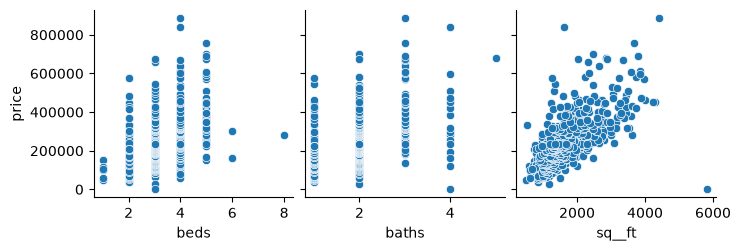

In [23]:
sns.pairplot(housing,x_vars= col_feature, y_vars='price')

### 5. Write a function that will take in two lists, `x` and `y`, and return the intercept and slope coefficients that minimize SSE. 

`y` is the target variable, and `x` is the predictor variable.

**Don't use `scikit-learn` for this**. Instead, use `numpy`.

The slope and intercept of simple linear regression can be calculated by using certain summary statistics. In particular, we'll need to know:

- $\bar{x}$, the mean of `x`
- $\bar{y}$, the mean of `y`
- $s_{x}$, the standard deviation of `x`
- $s_{y}$, the standard deviation of `y`
- $r_{xy}$, the correlation of `x` and `y`

Given these summary statistics, the **coefficient on `X`** (or the slope) can be given by $\beta_{1} = r_{xy} * \frac{s_{y}}{s_{x}}$. The **intercept of the model** can be given by $\beta_{0} = \bar{y} - \beta_{1}\bar{x}$.

Your function should take in `x` and `y`, then use the above summary statistics to calculate the slope and intercept.

- **Test your function on price and the variable you determined was the best predictor in Problem 4.**
- **Report the slope and intercept.**

In [24]:
def simple_linear_regression(x,y):
    x= np.array(x)
    y= np.array(y)

    x_bar = np.mean(x)
    y_bar = np.mean(y)
    std_x= np.std(x)
    std_y = np.std(y)
    r_xy = np.corrcoef(x, y)[0, 1]
    
    beta_1 = r_xy * (std_y / std_x)
    beta_0 = y_bar - beta_1 * x_bar
    
    return print(f"The intercept estimator is {round(beta_0, ndigits=2)}, and the slope estimator is {round(beta_1, ndigits=2)}")


x = housing_cleaned["sq__ft"]
y= housing_cleaned["price"]
simple_linear_regression(x, y)

The intercept estimator is 29984.36, and the slope estimator is 125.31


### 6. Interpret the intercept and the slope.

### 7. Give an example of how this model could be used for prediction and how it could be used for inference. 

**Be sure to make it clear which example is associated with prediction and which is associated with inference.**

### 8: [Bonus] Using the model you came up with in Problem 5, calculate and plot the residuals.

---

## Dummy Variables

It is important to be cautious with categorical variables, which represent distict groups or categories, when building a regression. If put in a regression "as-is," categorical variables represented as integers will be treated like *continuous* variables.

That is to say, instead of group "3" having a different effect on the estimation than group "1" it will estimate literally 3 times more than group 1. 

For example, if occupation category "1" represents "analyst" and occupation category "3" represents "barista", and our target variable is salary, if we leave this as a column of integers then barista will always have `beta*3` the effect of analyst.

This will almost certainly force the beta coefficient to be something strange and incorrect. Instead, we can re-represent the categories as multiple "dummy coded" columns.



#### A Word of Caution When Creating Dummies

Let's touch on precautions we should take when dummy coding.

**If you convert a qualitative variable to dummy variables, you want to turn a variable with N categories into N-1 variables.**

> **Scenario 1:** Suppose we're working with the variable "sex" or "gender" with values "M" and "F". 

You should include in your model only one variable for "sex = F" which takes on 1 if sex is female and 0 if sex is not female! Rather than saying "a one unit change in X," the coefficient associated with "sex = F" is interpreted as the average change in Y when sex = F relative to when sex = M.

| Female | Male | 
|-------|------|
| 0 | 1 | 
| 1 | 0 |
| 0 | 1 |
| 1 | 0 |
| 1 | 0 |
_As we can see a 1 in the female column indicates a 0 in the male column. And so, we have two columns stating the same information in different ways._

> Scenario 2: Suppose we're modeling revenue at a bar for each of the days of the week. We have a column with strings identifying which day of the week this observation occured in.

We might include six of the days as their own variables: "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday". **But not all 7 days.**  

|Monday | Tuesday | Wednesday | Thursday | Friday | Saturday | 
|-------|---------|-----------|----------|--------|----------|
| 1     | 0       |0          |      0   |0       | 0        | 
| 0     | 1       |0          |      0   |0       | 0        | 
| 0     | 0       |1          |      0   |0       | 0        | 
| 0     | 0       |0          |      1   |0       | 0        | 
| 0     | 0       |0          |      0   |1       | 0        | 
| 0     | 0       |0          |      0   |0       | 1        | 
| 0     | 0       |0          |      0   |0       | 0        | 

_As humans we can infer from the last row that if its is not Monday, Tuesday, Wednesday, Thursday, Friday or Saturday, it must be Sunday. Models work the same way._

The coefficient for Monday is then interpreted as the average change in revenue when "day = Monday" relative to "day = Sunday." The coefficient for Tuesday is interpreted as the average change in revenue when "day = Tuesday" relative to "day = Sunday" and so on.

The category you leave out, which the other columns are *relative to*, is often referred to as the **reference category**.

### 9. Use the `pd.get_dummies` function to convert the `type` column into dummy-coded variables.

In [25]:
housing_cleaned_dummies = pd.get_dummies(housing_cleaned['type'], dtype=int, drop_first=True)

### 10. Check the dummy columns you've created. Do they all make sense?

Use `.head()` on the new dataframe you've created. Depending on how you cleaned the data earlier in this notebook, there may be a dummy column that needs to be removed. Check that all the columns you've created make sense, and if any of the columns seem to be errors, drop them. If there don't appear to be any errors, then move on to the next step!

In [26]:
housing_cleaned = pd.concat([housing_cleaned, housing_cleaned_dummies], axis=1)

housing_cleaned.head()

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude,Multi-Family,Residential
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,Residential,2008-05-21,59222,38.631913,-121.434879,0,1
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,2008-05-21,68212,38.478902,-121.431028,0,1
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,Residential,2008-05-21,68880,38.618305,-121.443839,0,1
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,Residential,2008-05-21,69307,38.616835,-121.439146,0,1
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,Residential,2008-05-21,81900,38.519470,-121.435768,0,1


### 11. Build what you think may be the best MLR model predicting `price`. 

Choose at least three variables, and build a model that uses them to predict price. At least one of the variables you choose should be a dummy-coded variable. (This can be one we created before or a new one.) 

You may need to load in the scikit-learn API:

```python
from sklearn.linear_model import LinearRegression

model = LinearRegression()
```

In [27]:
housing_cleaned.columns

Index(['street', 'city', 'zip', 'state', 'beds', 'baths', 'sq__ft', 'type',
       'sale_date', 'price', 'latitude', 'longitude', 'Multi-Family',
       'Residential'],
      dtype='str')

In [28]:
from sklearn.linear_model import LinearRegression

feature_cols = ['sq__ft', 'beds', 'Residential', 'Multi-Family']
X = housing_cleaned[feature_cols]
y = housing_cleaned['price']

model = LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 134.97,-12471.82, 33214.33,-20525.73]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['sq__ft','beds','Residential','Multi-Family']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.444e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


### 12. Plot the true price vs the predicted price to evaluate your MLR visually.

You can use matplotlib or seaborn.

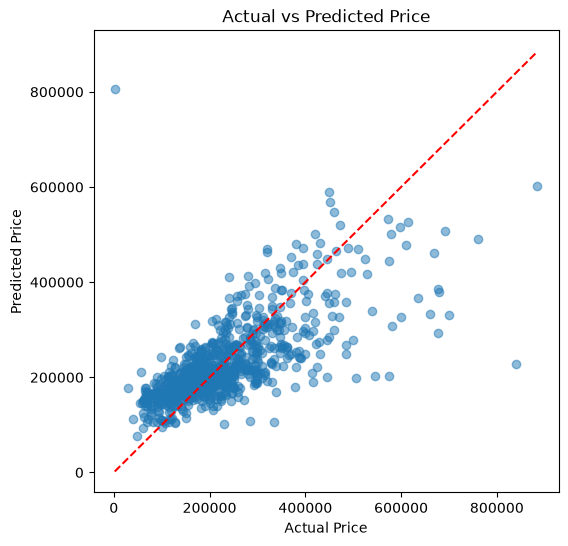

In [29]:
from sklearn.metrics import PredictionErrorDisplay

y_pred = model.predict(X)

plt.figure(figsize=(6,6))
plt.scatter(y, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', linestyle='--')  # perfect prediction line
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price')
plt.show()

### 13. List the five assumptions for an MLR model. 

Indicate which ones are the same as the assumptions for an SLR model. 

1. Linearity
2. Independence (errors must be independent)
3. Normality (residuals follow a normal distribution)
4. Equality of variance (the residuals have a consistent pattern)
5. Independence of predictors

Assumptions similar to SLR:
All the above except for independence of predictors.


### 14. Pick at least two assumptions and explain whether or not you believe them to be met for your model, and explain why.

1. Linearity isnt fully met, as seen from the Actaul vs Predicted plot shows a close linear relationship. The model underpredicts some high value houses, and overpredicts very expensive homes.
2.  There is no constant variance of residuals, homoscedasticity is not met. Becuase the plot fans out as price and sq__ft increases.

In [30]:
def r2_adj(y_true, y_pred, X):
    r2 = r2_score(y_true, y_pred)
    
    n = X.shape[0]  # Number of samples
    k = X.shape[1]  # Number of predictors
    
    r2_adjusted = 1 - ((1 - r2) * (n - 1) / (n - k - 1))
    return r2_adjusted

r2_adj_value = r2_adj(y, y_pred, X)
print(f" R-sqaured: {r2_score(y, y_pred)}")
print(f"Adjusted R-Squared: {round(r2_adj_value, 4)}")

 R-sqaured: 0.49105660923882166
Adjusted R-Squared: 0.4885


### 17. Metrics, metrics, everywhere...

Calculate and interpret at least three regression metrics. How well does your model perform?

In [31]:

print(f"RMSE: {mean_squared_error(y, y_pred)**0.5}, MAE: {mean_absolute_error(y, y_pred)}, R-Sqaured Score: {r2_score(y, y_pred)}")


RMSE: 85482.6323677441, MAE: 59050.670143676354, R-Sqaured Score: 0.49105660923882166


### 18. Model Iteration

Adjust your model by adding or removing a variable. Then calculate the same regression metrics as you used in question 17. Has your model performance increased or decreased?

**Guidance:**
1. Look at the correlation between the dependent and independent variables. Which two predictors are the most correlated with each other?
2. Drop the one you think is less useful and refit the model with the remaining features.
3. Compare the new R2 and RMSE to your original model from Q11/Q17.


In [32]:
model2 = LinearRegression()
X = housing_cleaned[["sq__ft", "Multi-Family","Residential"]]
y= housing_cleaned["price"]

model2.fit(X, y)
y_pred = model2.predict(X)

rmse = round(np.sqrt(mean_squared_error(y, y_pred)), ndigits=3)
r2 = round(r2_score(y, y_pred), ndigits= 3)

print("The rmse:", rmse)
print("The r2:", r2)

The rmse: 85780.078
The r2: 0.488


### 19. Add `city` as a feature

Use `OneHotEncoder` on the `city` column to add location as a feature. Since some cities only have 1-2 sales, group cities with fewer than 20 sales into `'Other'` first. Compare R2 and RMSE to the base model.

In [37]:
# showing the count of cities
city_counts = housing_cleaned["city"].value_counts()
# grouping cities less than 20 as "Other"
rare_cities = city_counts[city_counts < 20].index
housing_cleaned["city"] = housing_cleaned["city"].replace(rare_cities, "Other")
# One-Hot Encoding for the city column, drop_first=True helps avoid multicollinearity
city_encoded = pd.get_dummies(housing_cleaned["city"], prefix="city", drop_first=True)

In [38]:
# combining the column features with city
X = pd.concat(
    [
        housing_cleaned[["sq__ft", "Multi-Family", "Residential"]].reset_index(drop=True),
        city_encoded.reset_index(drop=True),
    ],
    axis=1,
)
y = housing_cleaned["price"]

In [36]:
model3 = LinearRegression()
model3.fit(X, y)
y_pred = model3.predict(X)

rmse = round(np.sqrt(mean_squared_error(y, y_pred)), 3)
r2 = round(r2_score(y, y_pred), 3)

print("The rmse:", rmse)
print("The r2:", r2)

The rmse: 79698.999
The r2: 0.558


## Part 2: Sacramento Real Estate Deep Dive & Model Diagnostics

---

### 21. Beating the Baseline
A machine learning model is only useful if it performs better than a "naive guess". Create a baseline model:

Calculate the mean `price` of your training data to get the "Baseline" prediction, then, report how much money "on average" does your MLR model save us in pricing errors compared to just guessing using the average?

In [46]:
# calculating the mean and creating an array
baseline_pred = np.ones(len(y)) * y.mean()
baseline_rmse = np.sqrt(mean_squared_error(y, baseline_pred))
baseline_mae = mean_absolute_error(y, baseline_pred)

mlr3_rmse = np.sqrt(mean_squared_error(y, y_pred))
mlr3_mae = mean_absolute_error(y, y_pred)

rmse_savings = baseline_rmse - mlr3_rmse
mae_savings = baseline_mae - mlr3_mae

print(f"Baseline RMSE: {baseline_rmse:.3f}")
print(f"MLR Model RMSE: {mlr3_rmse:.3f}")
print(f"RMSE Error  (Average Savings): ${rmse_savings:}")
print(f"MAE Error (Average Savings): ${mae_savings:}")

Baseline RMSE: 119823.816
MLR Model RMSE: 79698.999
RMSE Error  (Average Savings): $40124.81749837662
MAE Error (Average Savings): $34567.65662738904


### 22. Which Feature Matters Most?
To explain our model accurately, we use **Feature Scaling** to force all features to be on a similar scale, allowing us to compare their "weight" equally.

Fit a new Linear Regression model on this **scaled** training data and find the new coefficients. Based on these scaled coefficients, which feature does the model actually rely on the most to determine a house's price?

In [48]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

scaled_model = LinearRegression()
scaled_model.fit(X_scaled, y)


coef_housing_cleaned = pd.DataFrame({"Feature": X.columns, "Scaled_Coefficient": scaled_model.coef_})


coef_housing_cleaned["Abs_Coefficient"] = coef_housing_cleaned["Scaled_Coefficient"].abs()
coef_housing_cleaned = coef_housing_cleaned.sort_values(by="Abs_Coefficient", ascending=False)

print(coef_housing_cleaned)

                 Feature  Scaled_Coefficient  Abs_Coefficient
0                 sq__ft        76102.669758     76102.669758
8             city_Other        27362.625397     27362.625397
3        city_CARMICHAEL        13232.850484     13232.850484
10        city_ROSEVILLE        10654.227204     10654.227204
2            Residential         7241.124954      7241.124954
7   city_NORTH HIGHLANDS        -5197.300498      5197.300498
5         city_ELK GROVE         3108.992878      3108.992878
1           Multi-Family        -2509.624484      2509.624484
11       city_SACRAMENTO        -2423.496549      2423.496549
6              city_GALT         1019.155578      1019.155578
9    city_RANCHO CORDOVA         -951.487162       951.487162
4    city_CITRUS HEIGHTS          729.256780       729.256780


### 23. Does the model generalize to the real world?
A model that perfectly memorizes the training data but fails completely on new unseen houses is useless. We call a model's ability to succeed on new data **Generalization**.

Using your scaled MLR model from Question 22:

* **Step 1:** Predict prices for the **training** set and calculate the training RMSE.

* **Step 2:** Predict prices for the **testing** set and calculate the testing RMSE.

Is the model performing significantly worse on the test data? What does this tell you about how the model generalizes?

In [49]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

scaled_model.fit(X_train, y_train)
y_train_pred = scaled_model.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

y_test_pred = scaled_model.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"Training RMSE: {train_rmse:}")
print(f"Testing RMSE: {test_rmse:}")

Training RMSE: 80030.42100853239
Testing RMSE: 79102.44656994051


### 24. The Bias-Variance Tradeoff

In machine learning, there is a constant battle between Bias and Variance:
* **High Bias (Underfitting):** The model is very simple. It performs poorly on the training data as well as on the testing data.
* **High Variance (Overfitting):** The model is very complex. It memorizes the training data (high R-squared) but performs terribly on unseen testing data.
* **The Sweet Spot:** The model performs well on both the training set and the test set, with very little drop-off in performance.

Looking back at the Train and Test metrics you calculated for your Multiple Linear Regression model, is your model suffering from High Bias, High Variance, or is it in the sweet spot? Explain your reasoning.

The sweet spot

### 25. Force High Variance to compare the outcomes
Let's see what the Bias-Variance Tradeoff looks like when we break the model on purpose! 

If we use `OneHotEncoder` on the `city` column **without** grouping the rare cities into "Other", we will a lot of new columns. Many of these columns will only have 1 or 2 houses in them. Explain the gap between the Train R-squared and Test R-squared.

### 26. Interpreting & Explaining Results to Non-Technical Audiences
Data science is useless if the business doesn't understand your results. Avoid using technical jargon. How would you translate your model's performance for the executives?